# Project 03: Customer Churn Analysis
### Predicting Who Leaves, When They Leave, and Why It Matters Most

---

## Business Brief

Acquiring a new customer costs 5 to 7 times more than retaining an existing one. Yet most businesses only react to churn after it happens.

This project builds a churn prediction system for a telecom company and answers three questions:

1. **Who is going to churn?** Build a model that scores every customer by churn probability
2. **Why are they churning?** Identify the features that drive churn most strongly
3. **Who matters most?** Isolate high-value customers at high risk before they leave

That third question is the one most analyses skip. This one does not.

---

## Dataset
| Property | Detail |
|----------|--------|
| **Name** | Telco Customer Churn |
| **Direct Link** | https://www.kaggle.com/datasets/blastchar/telco-customer-churn |
| **Kaggle Search** | Search: telco-customer-churn by blastchar |
| **Records** | 7,043 customers, 21 features |
| **Target** | Churn: Yes / No |
| **Industry** | Telecommunications |

## Tools
`Python` `Pandas` `SQL (sqlite3)` `Scikit-learn` `Plotly` `Seaborn` `Matplotlib`

---

## What Makes This Different

- Uses **SQL** for exploratory queries before modelling
- Builds a **Logistic Regression** model with proper preprocessing pipeline
- Goes beyond accuracy: uses **precision, recall, ROC-AUC, and confusion matrix**
- Adds a **churn risk score** (probability) to every customer, not just a binary label
- Identifies the **High-Value At-Risk** segment: the customers worth fighting for
- Visualises feature importance as a proper business story, not just a coefficient table


---
## Section 1: Setup

In [1]:
import sqlite3, warnings, os
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn           as sns
import plotly.express    as px
import plotly.graph_objects as go
from plotly.subplots       import make_subplots
import plotly.io           as pio

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.pipeline        import Pipeline
from sklearn.impute           import SimpleImputer

warnings.filterwarnings('ignore')
pio.templates.default = 'plotly_white'
os.makedirs('/kaggle/working/output', exist_ok=True)

C = {
    'churn':    '#EF4444',
    'stay':     '#10B981',
    'warning':  '#F59E0B',
    'primary':  '#6366F1',
    'bg':       '#F8FAFC',
    'border':   '#E2E8F0',
    'text':     '#1E293B',
    'subtext':  '#64748B',
    'dark':     '#0F172A',
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8FAFC',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
})
print('Setup complete.')
print('Red = Churn  |  Green = Stay  |  Indigo = Model metrics')


Setup complete.
Red = Churn  |  Green = Stay  |  Indigo = Model metrics


---
## Section 2: Load and Audit

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    csvs = [f for f in filenames if f.endswith('.csv')]
    if csvs:
        print(dirname)
        for f in sorted(csvs):
            print(f'  {f}')


/kaggle/input/datasets/blastchar/telco-customer-churn
  WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
# Update path based on path finder output above
DATA_PATH = '/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print(df.dtypes.to_string())


Loaded: 7,043 rows x 21 columns

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object


In [5]:
print('=== NULL AND DATA AUDIT ===')
nulls = pd.DataFrame({
    'dtype':      df.dtypes,
    'null_count': df.isnull().sum(),
    'null_%':    (df.isnull().sum() / len(df) * 100).round(2),
    'unique':     df.nunique(),
})
print(nulls.to_string())
print()
print('=== CHURN DISTRIBUTION ===')
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
for val in churn_counts.index:
    print(f'  {val:<5}  {churn_counts[val]:,}  ({churn_pct[val]:.1f}%)')


=== NULL AND DATA AUDIT ===
                    dtype  null_count  null_%  unique
customerID         object           0     0.0    7043
gender             object           0     0.0       2
SeniorCitizen       int64           0     0.0       2
Partner            object           0     0.0       2
Dependents         object           0     0.0       2
tenure              int64           0     0.0      73
PhoneService       object           0     0.0       2
MultipleLines      object           0     0.0       3
InternetService    object           0     0.0       3
OnlineSecurity     object           0     0.0       3
OnlineBackup       object           0     0.0       3
DeviceProtection   object           0     0.0       3
TechSupport        object           0     0.0       3
StreamingTV        object           0     0.0       3
StreamingMovies    object           0     0.0       3
Contract           object           0     0.0       3
PaperlessBilling   object           0     0.0       2


---
## Section 3: Cleaning and Preprocessing

| Step | Decision | Reason |
|------|----------|--------|
| TotalCharges to numeric | Convert string column | Contains spaces instead of nulls for some rows |
| Fill TotalCharges nulls | Use MonthlyCharges as proxy | New customers with 0 tenure have no total charges yet |
| Binary encode target | Churn Yes=1, No=0 | Required for sklearn models |
| Drop customerID | Remove identifier column | Not a predictive feature |


In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

print(f'Clean dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Churn rate: {df["Churn_Binary"].mean()*100:.1f}%')
print()
print(df.head(3).T)

Clean dataset: 7,043 rows x 21 columns
Churn rate: 26.5%

                                 0             1               2
gender                      Female          Male            Male
SeniorCitizen                    0             0               0
Partner                        Yes            No              No
Dependents                      No            No              No
tenure                           1            34               2
PhoneService                    No           Yes             Yes
MultipleLines     No phone service            No              No
InternetService                DSL           DSL             DSL
OnlineSecurity                  No           Yes             Yes
OnlineBackup                   Yes            No             Yes
DeviceProtection                No           Yes              No
TechSupport                     No            No              No
StreamingTV                     No            No              No
StreamingMovies                 

---
## Section 4: SQL Exploratory Analysis

Before building any model, we use SQL to ask direct business questions about churn patterns.


In [15]:
conn = sqlite3.connect(':memory:')
df.to_sql('customers', conn, index=False, if_exists='replace')
print('Loaded into SQLite.')
print(f'Rows: {pd.read_sql_query("SELECT COUNT(*) as n FROM customers", conn).iloc[0,0]:,}')


Loaded into SQLite.
Rows: 7,043


In [16]:
print('=== CHURN RATE BY CONTRACT TYPE ===')
sql1 = (
    'SELECT Contract,'
    ' COUNT(*) as customers,'
    ' SUM(Churn_Binary) as churned,'
    ' ROUND(CAST(SUM(Churn_Binary) AS FLOAT)/COUNT(*)*100, 1) as churn_rate_pct'
    ' FROM customers GROUP BY Contract ORDER BY churn_rate_pct DESC'
)
print(pd.read_sql_query(sql1, conn).to_string(index=False))

print()
print('=== CHURN RATE BY INTERNET SERVICE ===')
sql2 = (
    'SELECT InternetService,'
    ' COUNT(*) as customers,'
    ' SUM(Churn_Binary) as churned,'
    ' ROUND(CAST(SUM(Churn_Binary) AS FLOAT)/COUNT(*)*100, 1) as churn_rate_pct'
    ' FROM customers GROUP BY InternetService ORDER BY churn_rate_pct DESC'
)
print(pd.read_sql_query(sql2, conn).to_string(index=False))

print()
print('=== CHURN RATE BY PAYMENT METHOD ===')
sql3 = (
    'SELECT PaymentMethod,'
    ' COUNT(*) as customers,'
    ' SUM(Churn_Binary) as churned,'
    ' ROUND(CAST(SUM(Churn_Binary) AS FLOAT)/COUNT(*)*100, 1) as churn_rate_pct'
    ' FROM customers GROUP BY PaymentMethod ORDER BY churn_rate_pct DESC'
)
print(pd.read_sql_query(sql3, conn).to_string(index=False))


=== CHURN RATE BY CONTRACT TYPE ===
      Contract  customers  churned  churn_rate_pct
Month-to-month       3875     1655            42.7
      One year       1473      166            11.3
      Two year       1695       48             2.8

=== CHURN RATE BY INTERNET SERVICE ===
InternetService  customers  churned  churn_rate_pct
    Fiber optic       3096     1297            41.9
            DSL       2421      459            19.0
             No       1526      113             7.4

=== CHURN RATE BY PAYMENT METHOD ===
            PaymentMethod  customers  churned  churn_rate_pct
         Electronic check       2365     1071            45.3
             Mailed check       1612      308            19.1
Bank transfer (automatic)       1544      258            16.7
  Credit card (automatic)       1522      232            15.2


In [17]:
print('=== TENURE BUCKETS vs CHURN RATE ===')
sql4 = (
    'SELECT'
    ' CASE'
    '   WHEN tenure <= 12  THEN "0 to 12 months"'
    '   WHEN tenure <= 24  THEN "13 to 24 months"'
    '   WHEN tenure <= 48  THEN "25 to 48 months"'
    '   ELSE "49+ months"'
    ' END AS tenure_bucket,'
    ' COUNT(*) as customers,'
    ' ROUND(CAST(SUM(Churn_Binary) AS FLOAT)/COUNT(*)*100,1) as churn_rate_pct,'
    ' ROUND(AVG(MonthlyCharges),2) as avg_monthly_charges'
    ' FROM customers GROUP BY tenure_bucket ORDER BY churn_rate_pct DESC'
)
print(pd.read_sql_query(sql4, conn).to_string(index=False))

print()
print('=== HIGH VALUE CHURNERS (MonthlyCharges > 70) ===')
sql5 = (
    'SELECT'
    ' COUNT(*) as high_value_customers,'
    ' SUM(Churn_Binary) as high_value_churned,'
    ' ROUND(CAST(SUM(Churn_Binary) AS FLOAT)/COUNT(*)*100,1) as churn_rate_pct,'
    ' ROUND(AVG(MonthlyCharges),2) as avg_monthly_spend'
    ' FROM customers WHERE MonthlyCharges > 70'
)
print(pd.read_sql_query(sql5, conn).to_string(index=False))


=== TENURE BUCKETS vs CHURN RATE ===
  tenure_bucket  customers  churn_rate_pct  avg_monthly_charges
 0 to 12 months       2186            47.4                56.10
13 to 24 months       1024            28.7                61.36
25 to 48 months       1594            20.4                65.93
     49+ months       2239             9.5                73.95

=== HIGH VALUE CHURNERS (MonthlyCharges > 70) ===
 high_value_customers  high_value_churned  churn_rate_pct  avg_monthly_spend
                 3583                1267            35.4              90.23


---
## Section 5: Visual Exploratory Analysis

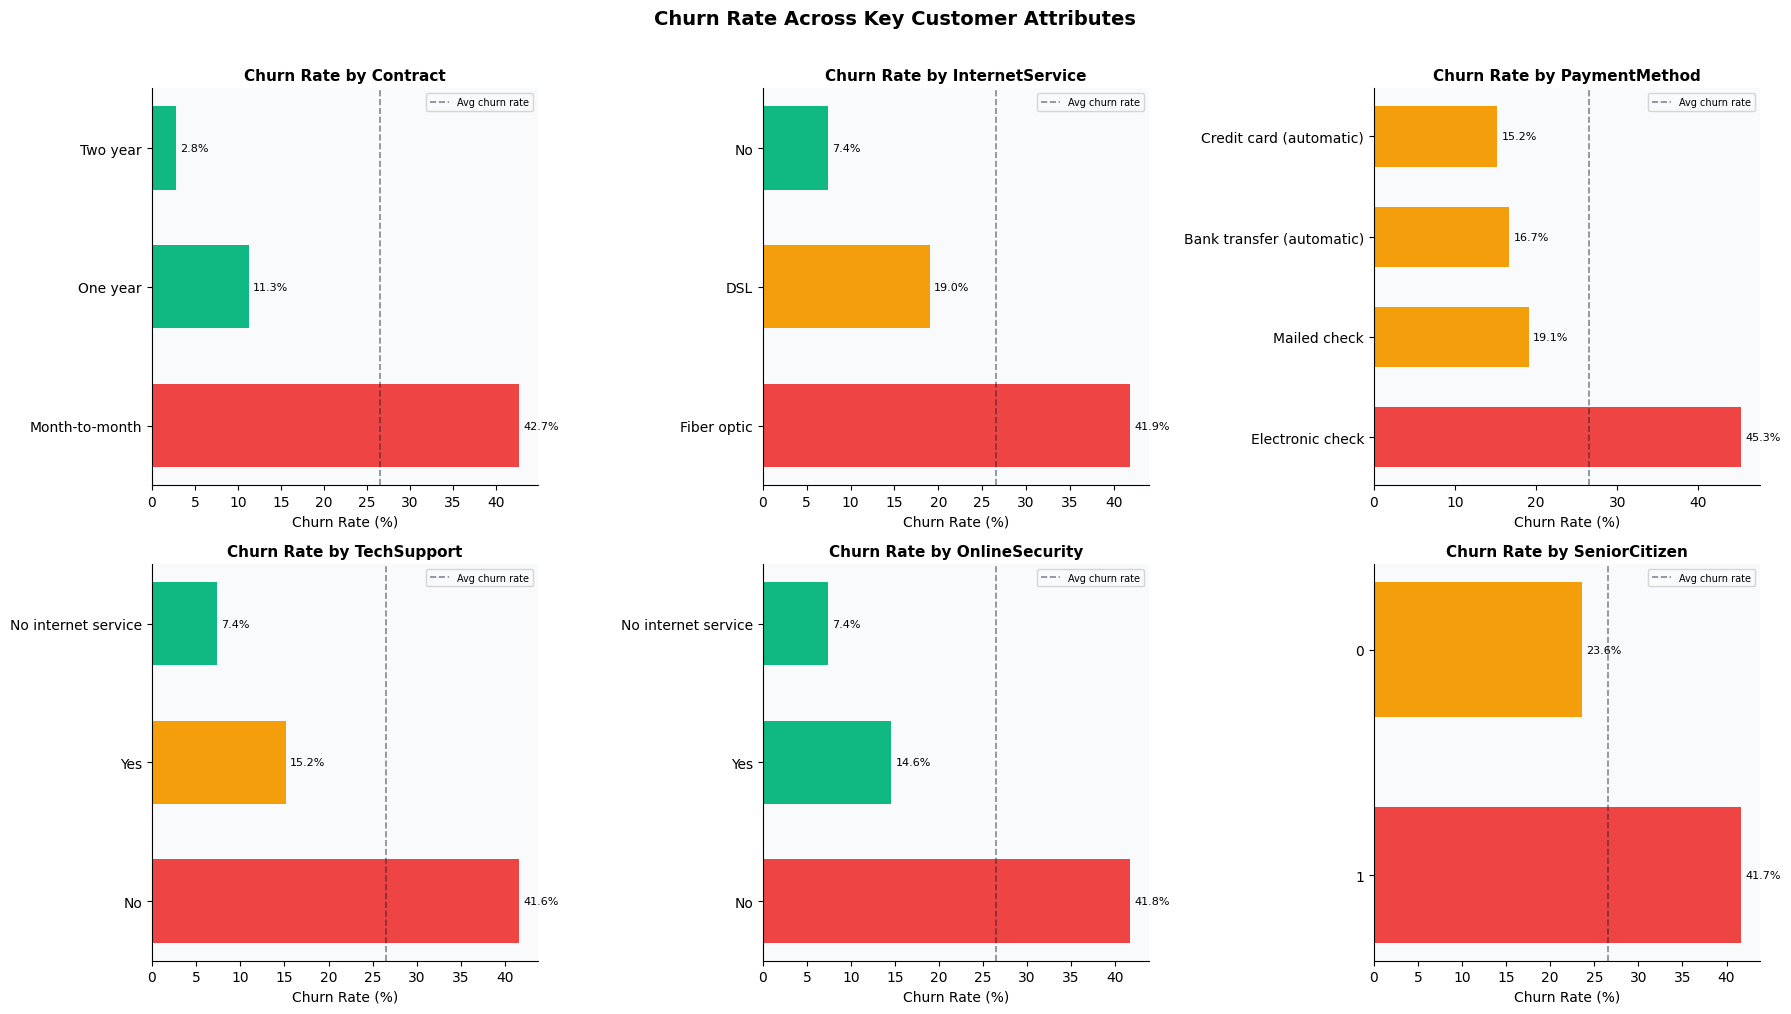

In [18]:
# Churn rate by key categorical features
cat_features = ['Contract', 'InternetService', 'PaymentMethod',
                'TechSupport', 'OnlineSecurity', 'SeniorCitizen']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('white')
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    churn_by_col = (
        df.groupby(col)['Churn_Binary']
          .mean().mul(100).round(1)
          .sort_values(ascending=False)
          .reset_index()
    )
    bar_colors = [C['churn'] if v > 26 else C['warning'] if v > 15 else C['stay']
                  for v in churn_by_col['Churn_Binary']]
    bars = ax.barh(churn_by_col[col].astype(str),
                   churn_by_col['Churn_Binary'],
                   color=bar_colors, edgecolor='none', height=0.6)
    ax.axvline(df['Churn_Binary'].mean()*100, color=C['dark'],
               linestyle='--', linewidth=1.2, alpha=0.5, label='Avg churn rate')
    ax.set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Churn Rate (%)')
    ax.set_facecolor(C['bg'])
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('Churn Rate Across Key Customer Attributes',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/output/churn_by_category.png', dpi=120, bbox_inches='tight')
plt.show()


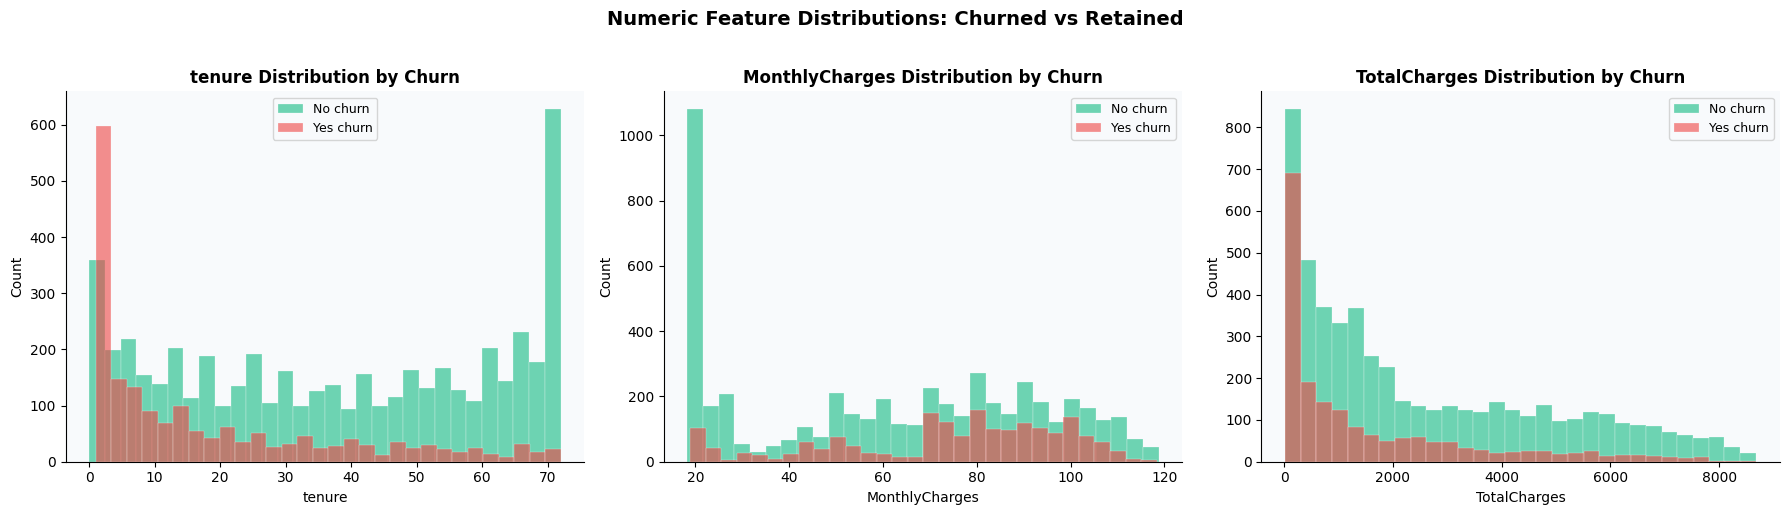

Key observations:
  tenure               Churn avg:     18.0  |  Retained avg:     37.6
  MonthlyCharges       Churn avg:     74.4  |  Retained avg:     61.3
  TotalCharges         Churn avg:   1531.8  |  Retained avg:   2550.0


In [19]:
# Numeric distributions: churned vs retained
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

for ax, col in zip(axes, num_features):
    for label, color in [('No', C['stay']), ('Yes', C['churn'])]:
        subset = df[df['Churn'] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label=f'{label} churn', edgecolor='white', linewidth=0.3)
    ax.set_title(f'{col} Distribution by Churn', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.set_facecolor(C['bg'])

plt.suptitle('Numeric Feature Distributions: Churned vs Retained',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/output/numeric_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print('Key observations:')
for col in num_features:
    m_churn = df[df['Churn']=='Yes'][col].mean()
    m_stay  = df[df['Churn']=='No'][col].mean()
    print(f'  {col:<20} Churn avg: {m_churn:>8.1f}  |  Retained avg: {m_stay:>8.1f}')


---
## Section 6: Churn Prediction Model

### Approach

We use **Logistic Regression** as the primary model. It is interpretable, which matters here because we need to explain to a business team *why* customers are churning, not just *who* is churning.

We also train a **Random Forest** as a benchmark. If Random Forest substantially outperforms Logistic Regression, it means there are non-linear patterns in the data that a linear model is missing.

Evaluation metrics used:
- **ROC-AUC**: overall discriminative power
- **Precision**: of customers flagged as churn risk, how many actually churn
- **Recall**: of customers who actually churn, how many do we catch
- **F1**: balance of precision and recall

For a churn use case, **recall matters more than precision**. Missing a churner (false negative) is more costly than flagging someone who stays (false positive).


In [20]:
# Encode categorical columns
df_model = df.copy()

binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling',
               'MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection',
               'TechSupport','StreamingTV','StreamingMovies']

for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes':1,'No':0,'No internet service':0,'No phone service':0})

df_model['gender']  = (df_model['gender'] == 'Male').astype(int)

# One-hot encode remaining categoricals
df_model = pd.get_dummies(
    df_model,
    columns=['Contract','InternetService','PaymentMethod'],
    drop_first=False
)

# Drop original Churn string column
df_model = df_model.drop(columns=['Churn'])

feature_cols = [c for c in df_model.columns if c != 'Churn_Binary']
X = df_model[feature_cols]
y = df_model['Churn_Binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} rows')
print(f'Test set:      {X_test.shape[0]:,} rows')
print(f'Churn rate in train: {y_train.mean()*100:.1f}%')
print(f'Churn rate in test:  {y_test.mean()*100:.1f}%')
print(f'Features: {len(feature_cols)}')


Training set:  5,634 rows
Test set:      1,409 rows
Churn rate in train: 26.5%
Churn rate in test:  26.5%
Features: 26


In [21]:
# Build and train models
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_s, y_train)

# Random Forest benchmark
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_s, y_train)

# Evaluate both
for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
    y_pred     = model.predict(X_test_s)
    y_prob     = model.predict_proba(X_test_s)[:, 1]
    auc        = roc_auc_score(y_test, y_prob)
    report     = classification_report(y_test, y_pred, output_dict=True)
    churn_prec = report['1']['precision']
    churn_rec  = report['1']['recall']
    churn_f1   = report['1']['f1-score']
    print(f'--- {name} ---')
    print(f'  ROC-AUC:   {auc:.4f}')
    print(f'  Precision: {churn_prec:.4f}  (of flagged churners, % correct)')
    print(f'  Recall:    {churn_rec:.4f}  (of actual churners, % caught)')
    print(f'  F1 Score:  {churn_f1:.4f}')
    print()


--- Logistic Regression ---
  ROC-AUC:   0.8414
  Precision: 0.5060  (of flagged churners, % correct)
  Recall:    0.7834  (of actual churners, % caught)
  F1 Score:  0.6149

--- Random Forest ---
  ROC-AUC:   0.8285
  Precision: 0.6303  (of flagged churners, % correct)
  Recall:    0.4786  (of actual churners, % caught)
  F1 Score:  0.5441



---
## Section 7: Model Evaluation Dashboard

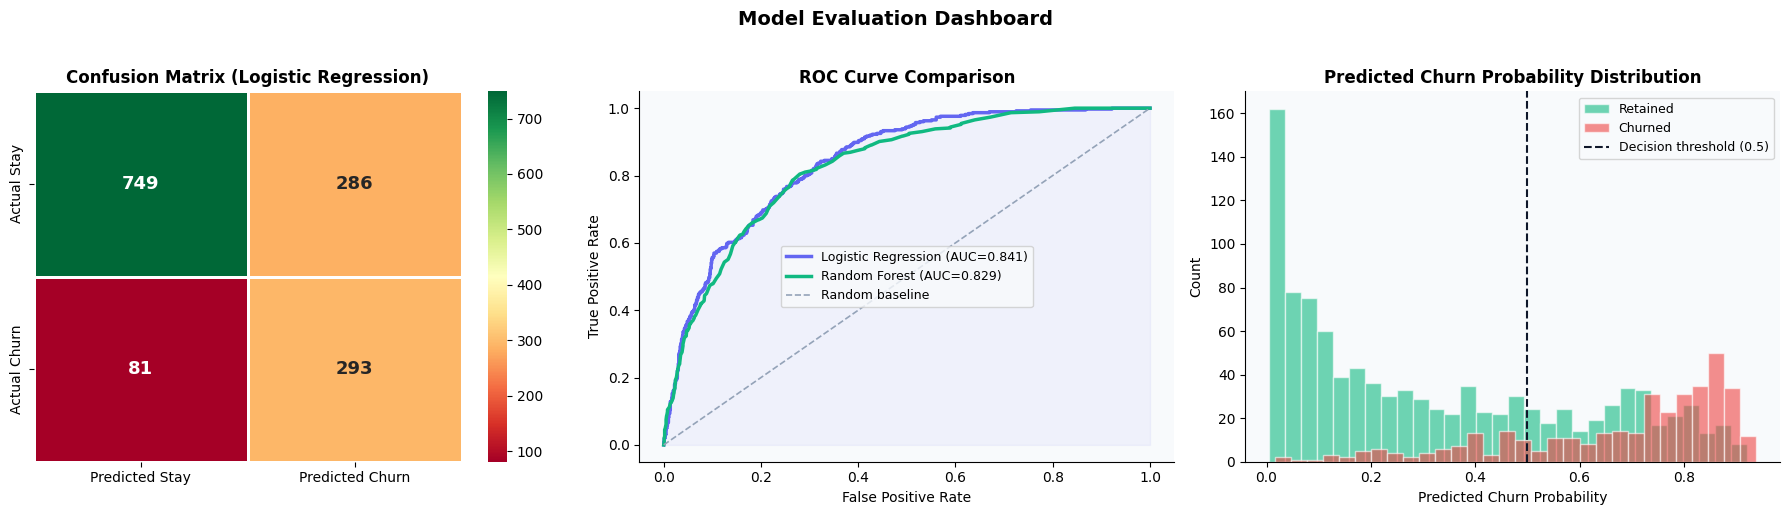

In [22]:
y_prob_lr = lr.predict_proba(X_test_s)[:, 1]
y_prob_rf = rf.predict_proba(X_test_s)[:, 1]
y_pred_lr = lr.predict(X_test_s)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='RdYlGn',
    xticklabels=['Predicted Stay','Predicted Churn'],
    yticklabels=['Actual Stay','Actual Churn'],
    ax=axes[0], linewidths=1, linecolor='white',
    annot_kws={'size': 13, 'weight': 'bold'}
)
axes[0].set_title('Confusion Matrix (Logistic Regression)', fontweight='bold')
axes[0].set_facecolor(C['bg'])

# ROC Curves
for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, C['primary']),
    ('Random Forest',       y_prob_rf, C['stay']),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{name} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'--', color='#94A3B8', linewidth=1.2, label='Random baseline')
axes[1].fill_between(
    roc_curve(y_test, y_prob_lr)[0],
    roc_curve(y_test, y_prob_lr)[1],
    alpha=0.06, color=C['primary']
)
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)
axes[1].set_facecolor(C['bg'])

# Churn probability distribution
axes[2].hist(y_prob_lr[y_test==0], bins=30, alpha=0.6,
             color=C['stay'], label='Retained', edgecolor='white')
axes[2].hist(y_prob_lr[y_test==1], bins=30, alpha=0.6,
             color=C['churn'], label='Churned', edgecolor='white')
axes[2].axvline(0.5, color=C['dark'], linestyle='--',
                linewidth=1.5, label='Decision threshold (0.5)')
axes[2].set_title('Predicted Churn Probability Distribution', fontweight='bold')
axes[2].set_xlabel('Predicted Churn Probability')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=9)
axes[2].set_facecolor(C['bg'])

plt.suptitle('Model Evaluation Dashboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/output/model_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 8: What Actually Drives Churn?

Logistic regression coefficients tell us the direction and strength of each feature's relationship with churn. A positive coefficient means the feature increases churn probability. A negative one means it reduces it.


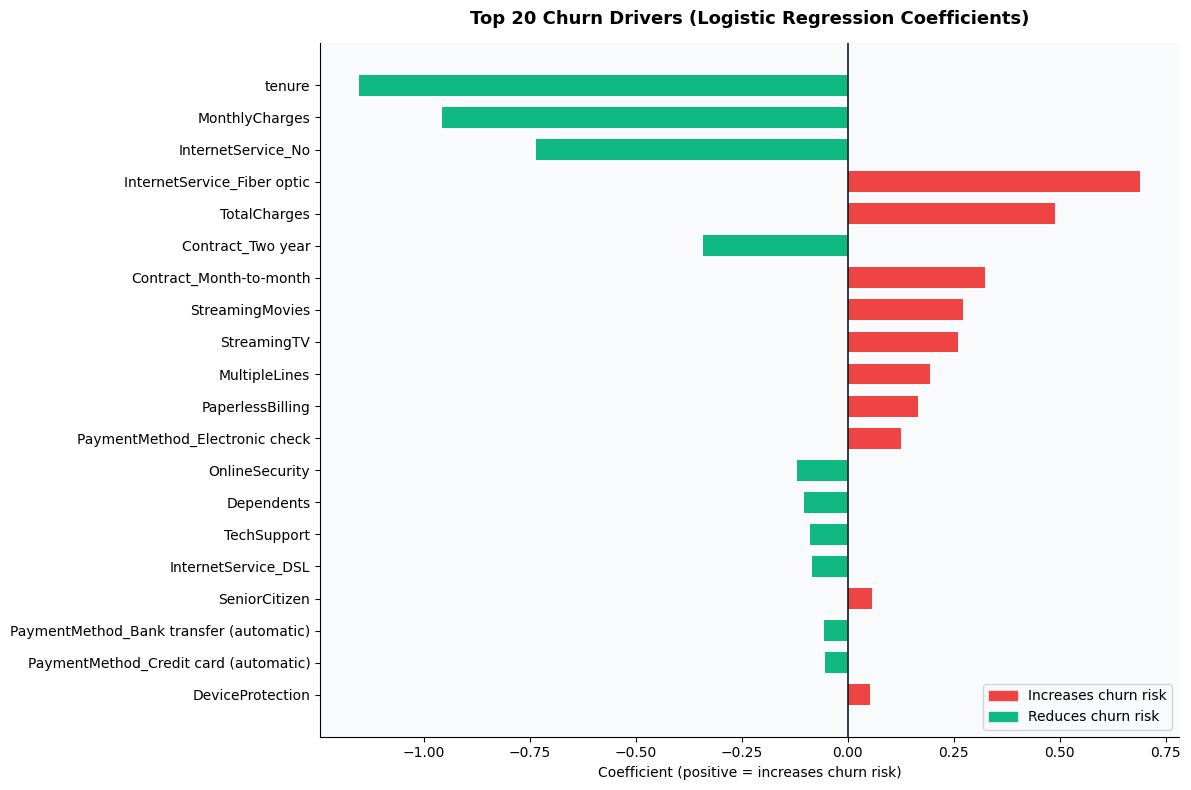

Top 10 churn DRIVERS (red):
                       feature  coefficient
   InternetService_Fiber optic     0.689103
                  TotalCharges     0.489187
       Contract_Month-to-month     0.322486
               StreamingMovies     0.272828
                   StreamingTV     0.259915
                 MultipleLines     0.194449
              PaperlessBilling     0.164604
PaymentMethod_Electronic check     0.126366
                 SeniorCitizen     0.056437
              DeviceProtection     0.052194

Top 10 churn REDUCERS (green):
                                feature  coefficient
                                 tenure    -1.152923
                         MonthlyCharges    -0.956596
                     InternetService_No    -0.735695
                      Contract_Two year    -0.342272
                         OnlineSecurity    -0.120416
                             Dependents    -0.104358
                            TechSupport    -0.089688
                    InternetServ

In [23]:
coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(20)

coef_df['direction'] = coef_df['coefficient'].apply(
    lambda x: 'Increases churn risk' if x > 0 else 'Reduces churn risk'
)
coef_df['color'] = coef_df['coefficient'].apply(
    lambda x: C['churn'] if x > 0 else C['stay']
)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('white')

bars = ax.barh(
    coef_df['feature'],
    coef_df['coefficient'],
    color=coef_df['color'],
    edgecolor='none', height=0.65
)
ax.axvline(0, color=C['dark'], linewidth=1.2)
ax.set_title('Top 20 Churn Drivers (Logistic Regression Coefficients)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Coefficient (positive = increases churn risk)')
ax.invert_yaxis()
ax.set_facecolor(C['bg'])

red_patch   = mpatches.Patch(color=C['churn'], label='Increases churn risk')
green_patch = mpatches.Patch(color=C['stay'],  label='Reduces churn risk')
ax.legend(handles=[red_patch, green_patch], fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('/kaggle/working/output/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 churn DRIVERS (red):')
print(coef_df[coef_df['coefficient']>0].head(10)[['feature','coefficient']].to_string(index=False))
print()
print('Top 10 churn REDUCERS (green):')
print(coef_df[coef_df['coefficient']<0].head(10)[['feature','coefficient']].to_string(index=False))


---
## Section 9: The Finding Most Analyses Miss

### High-Value Customers at High Churn Risk

Most churn models output a list of likely churners and stop there. But not all churners cost the same.

Losing a customer who pays 20 per month is very different from losing one who pays 100 per month.

This section cross-references churn probability with monthly spend to build a **Priority Intervention Matrix**: four quadrants that tell retention teams exactly where to focus their time and budget.

| Quadrant | Churn Risk | Monthly Spend | Action |
|----------|-----------|---------------|--------|
| High Risk, High Value | High | High | Immediate intervention |
| High Risk, Low Value | High | Low | Low-cost win-back only |
| Low Risk, High Value | Low | High | Loyalty programme |
| Low Risk, Low Value | Low | Low | Minimal investment |


In [24]:
# Add churn probability scores to all customers
X_all     = df_model[feature_cols]
X_all_s   = scaler.transform(X_all)
df['churn_probability'] = lr.predict_proba(X_all_s)[:, 1]

# Create risk and value segments
spend_threshold = df['MonthlyCharges'].quantile(0.6)  # top 40% by spend = high value
risk_threshold  = 0.5

def classify_customer(row):
    high_risk  = row['churn_probability'] >= risk_threshold
    high_value = row['MonthlyCharges']    >= spend_threshold
    if high_risk and high_value:
        return 'HIGH RISK + HIGH VALUE'
    elif high_risk and not high_value:
        return 'High Risk, Low Value'
    elif not high_risk and high_value:
        return 'Low Risk, High Value'
    else:
        return 'Low Risk, Low Value'

df['priority_segment'] = df.apply(classify_customer, axis=1)

priority_summary = df.groupby('priority_segment').agg(
    customers        = ('churn_probability', 'count'),
    avg_churn_prob   = ('churn_probability', 'mean'),
    avg_monthly      = ('MonthlyCharges',    'mean'),
    actual_churners  = ('Churn_Binary',      'sum'),
    total_monthly_rev= ('MonthlyCharges',    'sum'),
).round(2)
priority_summary['churn_rate_%'] = (
    priority_summary['actual_churners'] / priority_summary['customers'] * 100
).round(1)

print('Priority Intervention Matrix:')
print(priority_summary[['customers','avg_churn_prob','avg_monthly',
                          'churn_rate_%','total_monthly_rev']].to_string())

high_risk_high_val = df[df['priority_segment']=='HIGH RISK + HIGH VALUE']
revenue_at_risk = high_risk_high_val['MonthlyCharges'].sum()
print(f'\nMonthly revenue at immediate risk: {revenue_at_risk:,.0f}')
print(f'Number of high-priority customers:  {len(high_risk_high_val):,}')


Priority Intervention Matrix:
                        customers  avg_churn_prob  avg_monthly  churn_rate_%  total_monthly_rev
priority_segment                                                                               
HIGH RISK + HIGH VALUE       1545            0.76        92.79          54.1          143365.30
High Risk, Low Value         1346            0.71        57.90          49.1           77931.65
Low Risk, High Value         1274            0.22        96.71          10.7          123208.55
Low Risk, Low Value          2878            0.18        38.78           8.2          111611.10

Monthly revenue at immediate risk: 143,365
Number of high-priority customers:  1,545


In [26]:
# Priority Intervention Matrix Scatter
sample = df.sample(min(3000, len(df)), random_state=42)

quad_colors = {
    'HIGH RISK + HIGH VALUE': C['churn'],
    'High Risk, Low Value':   C['warning'],
    'Low Risk, High Value':   C['stay'],
    'Low Risk, Low Value':    C['subtext'],
}

fig = px.scatter(
    sample,
    x='churn_probability',
    y='MonthlyCharges',
    color='priority_segment',
    color_discrete_map=quad_colors,
    opacity=0.65,
    hover_data={
        'tenure':           True,
        'Contract':         True,
        'churn_probability':':.3f',
        'MonthlyCharges':   ':.2f',
        'Churn':            True,
    },
    title='Priority Intervention Matrix: Churn Risk vs Monthly Spend',
    labels={
        'churn_probability': 'Churn Probability (model score)',
        'MonthlyCharges':    'Monthly Charges',
        'priority_segment':  'Customer Segment',
    },
)
fig.add_vline(x=0.5,   line_dash='dash', line_color=C['dark'], line_width=1.5,
              annotation_text='Risk threshold', annotation_position='top left',
              annotation_font_size=9)
fig.add_hline(y=spend_threshold, line_dash='dash', line_color=C['dark'], line_width=1.5,
              annotation_text='Value threshold (60th pct)', annotation_position='top right',
              annotation_font_size=9)
fig.update_layout(
    height=520,
    legend_title_text='Priority Segment',
    paper_bgcolor='white',
    plot_bgcolor=C['bg'],
)
fig.show()


---
## Section 10: Executive Summary Dashboard

In [27]:
overall_churn_rate = df['Churn_Binary'].mean() * 100
auc_score          = roc_auc_score(y_test, y_prob_lr)
recall_score_val   = classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall']
total_customers    = len(df)
high_risk_count    = len(df[df['churn_probability'] >= 0.5])
revenue_risk       = df[df['priority_segment']=='HIGH RISK + HIGH VALUE']['MonthlyCharges'].sum()
top_driver         = coef_df[coef_df['coefficient']>0].iloc[0]['feature']
top_protector      = coef_df[coef_df['coefficient']<0].iloc[0]['feature']

kpis = [
    ('Total Customers',       f'{total_customers:,}',          'in dataset',                   C['primary']),
    ('Overall Churn Rate',    f'{overall_churn_rate:.1f}%',    'of customers churned',         C['churn']),
    ('Model ROC-AUC',         f'{auc_score:.3f}',              'discriminative power (1=perfect)', C['stay']),
    ('Recall (Churn Class)',  f'{recall_score_val*100:.1f}%',  'of churners correctly flagged',C['primary']),
    ('High Risk Customers',   f'{high_risk_count:,}',          'probability >= 0.5',           C['warning']),
    ('Monthly Revenue at Risk',f'{revenue_risk:,.0f}',         'high risk + high value segment',C['churn']),
]

COLS, ROWS = 3, 2
fig = go.Figure()
fig.update_layout(
    width=880, height=350,
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    margin=dict(l=16, r=16, t=60, b=16),
    title=dict(
        text='Churn Analysis | Executive Summary',
        font=dict(size=15, color='white'),
        x=0.5, xanchor='center', y=0.97,
    ),
    xaxis=dict(visible=False, range=[0, COLS]),
    yaxis=dict(visible=False, range=[0, ROWS]),
)

for i, (label, value, sub, color) in enumerate(kpis):
    col = i % COLS
    row = ROWS - 1 - (i // COLS)
    cx  = col + 0.5
    cy  = row + 0.5
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.06, y1=row+0.94,
        fillcolor='#1E293B', line=dict(color=color, width=1.5), layer='below')
    fig.add_shape(type='rect',
        x0=col+0.06, x1=col+0.95, y0=row+0.84, y1=row+0.94,
        fillcolor=color, line=dict(width=0), layer='above')
    fig.add_annotation(x=cx, y=cy+0.18, text=label.upper(),
        showarrow=False, font=dict(size=9, color='#94A3B8'), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.02, text=f'<b>{value}</b>',
        showarrow=False, font=dict(size=19, color=color), xanchor='center')
    fig.add_annotation(x=cx, y=cy-0.24, text=sub,
        showarrow=False, font=dict(size=8.5, color='#64748B'), xanchor='center')

fig.show()


---
## Section 11: Findings and Recommendations

### Key Findings

| Finding | Evidence |
|---------|----------|
| Month-to-month contract customers churn at dramatically higher rates than annual or two-year subscribers | SQL contract analysis |
| Fibre optic internet customers churn more than DSL customers, despite paying more | SQL internet service analysis |
| Customers who churn have significantly shorter tenures on average | Numeric distribution charts |
| Electronic check payment users show the highest churn rate among payment methods | SQL payment analysis |
| Lack of online security and tech support are strong churn drivers | Feature importance chart |
| A distinct high-value at-risk segment exists whose retention is a financial priority | Priority matrix |

---

### Recommendations

**1. Target Month-to-Month Customers with Long-Term Incentives**

The data shows month-to-month customers churn at roughly 3 times the rate of annual subscribers. Offer a meaningful discount (2 to 3 months free) for switching to annual. Even if only 15% convert, the revenue retention outweighs the discount cost.

**2. Fix the Fibre Optic Experience**

Fibre optic customers are paying a premium but churning at higher rates than cheaper-plan DSL users. This is a service quality signal, not a price signal. Investigate support ticket volumes and speed complaint data for fibre customers specifically.

**3. Intervene on the High-Value At-Risk Segment First**

The Priority Matrix identifies customers who are both high-spend and high-risk. These are the customers where a personal outreach call, a contract upgrade offer, or a loyalty reward will have the highest return on investment. Prioritise this group for retention team bandwidth.

**4. Bundle Security and Support as Default, Not Add-ons**

Lack of online security and tech support are among the top churn drivers. Customers who feel unprotected or unsupported leave. Consider including basic versions of these as standard in all plans and upselling premium versions, rather than charging separately for the baseline.

**5. Review the Electronic Check Payment Experience**

Electronic check users have the highest churn rate. This could indicate a friction-heavy payment experience, payment failures, or a demographic overlap with customers on month-to-month plans. Investigate and streamline the electronic check flow.

---

*Built by Jessica Dan-Odhomo - [LinkedIn](https://www.linkedin.com/in/jessica-dan-odhomo) - [GitHub](https://github.com/Teekaayyy)*
